-	DSC 680: Week 5
-	Dat Science Competition
-	Martin Hoehler
-	4/19/26
## Spaceship Titanic Kaggle Competition

This will be my first Kaggle Competition, participating in the "Spaceship Titanic" competion.
https://www.kaggle.com/competitions/spaceship-titanic/discussion/329290

I plan to use many of the models I've used in previous courses, and attempt a little fine-tuning of the model that looks most promising.  I'll try my best to estimate missing values, and to engineer some useful features.

In [1]:
import pandas as pd
import numpy as np

# Display settings for cleaner browsing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [ ]:
### Import Data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


In [3]:
train.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


### Check for missing values.

In [5]:
missing = train.isna().mean().sort_values(ascending=False)
missing



CryoSleep       0.024963
ShoppingMall    0.023927
VIP             0.023352
HomePlanet      0.023122
Name            0.023007
Cabin           0.022892
VRDeck          0.021627
Spa             0.021051
FoodCourt       0.021051
Destination     0.020936
RoomService     0.020821
Age             0.020591
PassengerId     0.000000
Transported     0.000000
dtype: float64

In [6]:
# Does missingness correlate with target?
missing_vs_target = (
    train.assign(Transported=train.Transported.astype(int))
         .isna()
         .groupby(train.Transported.astype(int))
         .mean()
         .T
         .sort_values(by=1, ascending=False)
)

missing_vs_target


Transported,0,1
ShoppingMall,0.021784,0.026039
CryoSleep,0.025724,0.024212
VIP,0.022943,0.023755
HomePlanet,0.022711,0.023527
Name,0.022943,0.023070
Cabin,0.022943,0.022841
FoodCourt,0.019467,0.022613
VRDeck,0.020857,0.022385
Destination,0.020857,0.021014
Spa,0.021321,0.020786


### Missingness is uniform across "Transported"
It doesn't look like missing data in any field implies transported or not.  Missing data just looks randomly missing without any meaning.  So there's no need to preserve any "is missing" as a potential feature.

### Feature Extraction

In [7]:
def extract_cabin_features(df):
    # Split Cabin into Deck / Number / Side
    cabin_split = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin_split[0]
    df["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    df["Side"] = cabin_split[2]
    return df


In [8]:
def extract_passenger_group_features(df):
    # GroupID is the part before the underscore
    df["GroupID"] = df["PassengerId"].str.split("_").str[0]

    # Compute group sizes (requires groupby)
    group_sizes = df.groupby("GroupID")["PassengerId"].transform("count")
    df["GroupSize"] = group_sizes

    # Solo traveler flag
    df["IsSolo"] = (df["GroupSize"] == 1).astype(int)
    return df


In [9]:
def extract_spending_features(df):
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

    # Total spend
    df["TotalSpend"] = df[spend_cols].sum(axis=1)

    # Zero spend flag
    df["ZeroSpend"] = (df["TotalSpend"] == 0).astype(int)

    # Log transform (avoid -inf)
    df["LogSpend"] = np.log1p(df["TotalSpend"])
    return df


In [10]:
for dataset in [train, test]:
    dataset = extract_cabin_features(dataset)
    dataset = extract_passenger_group_features(dataset)
    dataset = extract_spending_features(dataset)


### Check to see if Group ID corresponds with any cabin info.
I hypothesize that if passengers belong to the same group, they likely stay in the same cabin.  If that's the case, I can use group ID to fill in some of the missing cabin assignments.

In [11]:
# Extract group and cabin info
tmp = train[["GroupID", "Deck", "CabinNum", "Side"]].copy()

# Count unique values per group
group_cabin_consistency = (
    tmp.groupby("GroupID")
       .agg({
           "Deck": "nunique",
           "CabinNum": "nunique",
           "Side": "nunique"
       })
)

group_cabin_consistency.head()


,Deck,CabinNum,Side
GroupID,,,
0001,1,1,1
0002,1,1,1
0003,1,1,1
0004,1,1,1
0005,1,1,1


In [12]:
group_cabin_consistency.head(20)



,Deck,CabinNum,Side
GroupID,,,
0001,1,1,1
0002,1,1,1
0003,1,1,1
0004,1,1,1
0005,1,1,1
0006,2,2,1
0007,1,1,1
0008,1,1,1
0009,1,1,1


In [13]:
consistency = group_cabin_consistency

deck_consistency_rate = (consistency["Deck"] == 1).mean()
side_consistency_rate = (consistency["Side"] == 1).mean()
cabin_num_consistency_rate = (consistency["CabinNum"] == 1).mean()

deck_consistency_rate, side_consistency_rate, cabin_num_consistency_rate


(np.float64(0.9163583722052436),
 np.float64(0.9840759208621521),
 np.float64(0.9165192214894644))

In [14]:
# Work on a copy to avoid modifying your original frame
df = train.copy()

# Extract GroupID if not already done
df["GroupID"] = df["PassengerId"].str.split("_").str[0]

# Only consider rows where Cabin is NOT missing
non_missing = df.dropna(subset=["Cabin"])

# Count unique cabin values per group
group_cabin_counts = (
    non_missing.groupby("GroupID")["Cabin"]
               .nunique()
)

# Groups with >1 unique cabin value
bad_groups = group_cabin_counts[group_cabin_counts > 1].index

# Show the actual conflicting cabin assignments
conflicting = (
    non_missing[non_missing["GroupID"].isin(bad_groups)]
        .sort_values(["GroupID", "Cabin"])
)

conflicting


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupSize,IsSolo,TotalSpend,ZeroSpend,LogSpend
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0,1584.0,0,7.368340
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,G,0.0,S,0006,2,0,0.0,1,0.000000
20,0017_02,Earth,False,F/6/P,55 Cancri e,14.0,False,412.0,0.0,1.0,0.0,679.0,Philda Brighttt,False,F,6.0,P,0017,2,0,1092.0,0,6.996681
19,0017_01,Earth,False,G/0/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Lyde Brighttt,True,G,0.0,P,0017,2,0,0.0,1,0.000000
59,0064_02,NaN,True,E/3/S,TRAPPIST-1e,33.0,False,0.0,0.0,NaN,0.0,0.0,Colatz Keen,True,E,3.0,S,0064,2,0,0.0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8655,9231_03,Mars,False,E/592/P,TRAPPIST-1e,22.0,False,0.0,0.0,0.0,0.0,0.0,Cus Paie,False,E,592.0,P,9231,3,0,0.0,1,0.000000
8653,9231_01,Mars,True,F/1888/P,55 Cancri e,2.0,False,0.0,0.0,0.0,0.0,0.0,Denuts Paie,True,F,1888.0,P,9231,3,0,0.0,1,0.000000
8654,9231_02,Mars,False,F/1888/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Walls Paie,True,F,1888.0,P,9231,3,0,0.0,1,0.000000
8683,9272_02,Earth,False,F/1894/P,TRAPPIST-1e,21.0,False,86.0,3.0,149.0,208.0,329.0,Gordo Simson,False,F,1894.0,P,9272,2,0,775.0,0,6.654153


### Impute Cabin
From the above analysis, I see that if that there are multiple passengers in a group, those passengers share the same cabin over 90% of the time.

So for any blank cabin fields, I'll check to see if there are any other members of the same group that do have cabin filled out, and use a lookup to fill it in.

In [15]:
# Combine train + test for consistent group-level imputation
full = pd.concat([train, test], ignore_index=True)

# Compute unique counts per group
group_stats = (
    full.groupby("GroupID")
        .agg({
            "Deck": "nunique",
            "CabinNum": "nunique",
            "Side": "nunique"
        })
)

# Keep only groups with exactly 1 unique value for each cabin component
consistent_groups = group_stats[
    (group_stats["Deck"] == 1) &
    (group_stats["CabinNum"] == 1) &
    (group_stats["Side"] == 1)
].index

# For each consistent group, get the single cabin assignment
group_cabin_lookup = (
    full[full["GroupID"].isin(consistent_groups)]
        .groupby("GroupID")
        .agg({
            "Deck": "first",
            "CabinNum": "first",
            "Side": "first"
        })
)

def impute_cabin_from_group(df, lookup):
    df = df.copy()
    for col in ["Deck", "CabinNum", "Side"]:
        df[col] = df.apply(
            lambda row: lookup.loc[row["GroupID"], col]
            if pd.isna(row[col]) and row["GroupID"] in lookup.index
            else row[col],
            axis=1
        )
    return df

full_imputed = impute_cabin_from_group(full, group_cabin_lookup)

# Reconstruct Cabin ONLY where all components are non-missing
mask = (
    full_imputed["Deck"].notna() &
    full_imputed["CabinNum"].notna() &
    full_imputed["Side"].notna()
)

full_imputed.loc[mask, "Cabin"] = (
    full_imputed.loc[mask, "Deck"].astype(str) + "/" +
    full_imputed.loc[mask, "CabinNum"].astype(int).astype(str) + "/" +
    full_imputed.loc[mask, "Side"].astype(str)
)


train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()



In [16]:
train_imputed.head(20)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupSize,IsSolo,TotalSpend,ZeroSpend,LogSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0001,1,1,0.0,1,0.000000
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,0002,1,1,736.0,0,6.602588
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,0003,2,0,10383.0,0,9.248021
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,0003,2,0,5176.0,0,8.551981
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,0004,1,1,1091.0,0,6.995766
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,F,0.0,P,0005,1,1,774.0,0,6.652863
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0,1584.0,0,7.368340
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,G,0.0,S,0006,2,0,0.0,1,0.000000
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,F,3.0,S,0007,1,1,1018.0,0,6.926577
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,B,1.0,P,0008,3,0,0.0,1,0.000000


In [17]:
missing_mask = (
    full_imputed["Deck"].isna() |
    full_imputed["CabinNum"].isna() |
    full_imputed["Side"].isna()
)

missing_count = missing_mask.sum()
missing_count



np.int64(181)

### Impute the remaining missing cabins
 - Cabin # imputed based on group.  (Lower groups tend to have lower room numbers)
 - Deck and Side are distrubuted randomly based on real distrubution.

In [18]:
# Real Side distribution
side_counts = full_imputed["Side"].value_counts(normalize=True, dropna=True)
p_side = side_counts.get("P", 0.5)
s_side = side_counts.get("S", 0.5)

# Real Deck distribution
deck_counts = full_imputed["Deck"].value_counts(normalize=True, dropna=True)
deck_values = deck_counts.index.tolist()
deck_probs = deck_counts.values.tolist()

# Fill missing Side
missing_side = full_imputed["Side"].isna()
full_imputed.loc[missing_side, "Side"] = np.random.choice(
    ["P", "S"], size=missing_side.sum(), p=[p_side, s_side]
)

# Fill missing Deck
missing_deck = full_imputed["Deck"].isna()
full_imputed.loc[missing_deck, "Deck"] = np.random.choice(
    deck_values, size=missing_deck.sum(), p=deck_probs
)
full_imputed["GroupID_num"] = full_imputed["GroupID"].astype(int)

def interpolate_cabin_by_group(df):
    df = df.copy()
    touched_idx = []

    for (deck, side), block in df.groupby(["Deck", "Side"], group_keys=False):
        known = block[block["CabinNum"].notna()]
        missing = block[block["CabinNum"].isna()]

        if len(known) < 2 or missing.empty:
            continue

        known = known.sort_values("GroupID_num")
        x = known["GroupID_num"].values
        y = known["CabinNum"].values

        m_idx = missing.index
        x_new = missing["GroupID_num"].values

        y_new = np.interp(x_new, x, y)

        df.loc[m_idx, "CabinNum"] = y_new
        touched_idx.extend(m_idx.tolist())

    return df, touched_idx

full_imputed, touched = interpolate_cabin_by_group(full_imputed)
full_imputed["CabinNum"] = full_imputed["CabinNum"].fillna(full_imputed["CabinNum"].median())
mask = (
    full_imputed["Deck"].notna() &
    full_imputed["CabinNum"].notna() &
    full_imputed["Side"].notna()
)

full_imputed.loc[mask, "Cabin"] = (
    full_imputed.loc[mask, "Deck"].astype(str) + "/" +
    full_imputed.loc[mask, "CabinNum"].round().astype(int).astype(str) + "/" +
    full_imputed.loc[mask, "Side"].astype(str)
)

train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()

In [19]:
train_imputed.head(20)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupSize,IsSolo,TotalSpend,ZeroSpend,LogSpend,GroupID_num
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0001,1,1,0.0,1,0.000000,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,0002,1,1,736.0,0,6.602588,2
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,0003,2,0,10383.0,0,9.248021,3
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,0003,2,0,5176.0,0,8.551981,3
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,0004,1,1,1091.0,0,6.995766,4
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,F,0.0,P,0005,1,1,774.0,0,6.652863,5
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0,1584.0,0,7.368340,6
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,G,0.0,S,0006,2,0,0.0,1,0.000000,6
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,F,3.0,S,0007,1,1,1018.0,0,6.926577,7
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,B,1.0,P,0008,3,0,0.0,1,0.000000,8


### Impute 0 spend for people in CryoSleep
Also, impute VIP = false... very few VIPs are in Cryo.

In [20]:
cols_to_zero = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# Zero out spending for CryoSleep passengers
full_imputed.loc[full_imputed["CryoSleep"] == True, cols_to_zero] = 0.0

# VIP should be False for CryoSleep passengers
full_imputed.loc[full_imputed["CryoSleep"] == True, "VIP"] = False


### Impute 0 spend in 1 missing category, if all other categories are 0
Assumes that if you didn't spend in 4 categories, you probably didn't spend in the 5th.  This appears true on inspection.

In [21]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# Count how many spending fields are zero
zero_count = (full_imputed[spend_cols] == 0).sum(axis=1)

# Identify rows where:
# - At least 4 spending fields are zero
# - AND at least one spending field is NaN
mask = (zero_count >= 4) & (full_imputed[spend_cols].isna().any(axis=1))

# Fill NaNs with 0 for those rows
full_imputed.loc[mask, spend_cols] = full_imputed.loc[mask, spend_cols].fillna(0)


### Impute Age, HomePlanet and Destination from Group if information exists, otherwise take ship average
Assumes people in a group are generally from the same place and going the same place, and average age of the group is likely to be a good estimate of age.

In [22]:
global_age_median = full_imputed["Age"].median()

# Group median age
group_age_median = full_imputed.groupby("GroupID")["Age"].transform("median")

# Fill group ages first
full_imputed.loc[full_imputed["IsSolo"] == 0, "Age"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 0, "Age"]
    .fillna(group_age_median)
)

# Solo fallback
full_imputed.loc[full_imputed["IsSolo"] == 1, "Age"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 1, "Age"]
    .fillna(global_age_median)
)

global_homeplanet_mode = full_imputed["HomePlanet"].mode()[0]

group_homeplanet_mode = (
    full_imputed.groupby("GroupID")["HomePlanet"]
                .transform(lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
)

# Group first
full_imputed.loc[full_imputed["IsSolo"] == 0, "HomePlanet"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 0, "HomePlanet"]
    .fillna(group_homeplanet_mode)
)

# Solo fallback
full_imputed.loc[full_imputed["IsSolo"] == 1, "HomePlanet"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 1, "HomePlanet"]
    .fillna(global_homeplanet_mode)
)

global_dest_mode = full_imputed["Destination"].mode()[0]

group_dest_mode = (
    full_imputed.groupby("GroupID")["Destination"]
                .transform(lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
)

# Group first
full_imputed.loc[full_imputed["IsSolo"] == 0, "Destination"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 0, "Destination"]
    .fillna(group_dest_mode)
)

# Solo fallback
full_imputed.loc[full_imputed["IsSolo"] == 1, "Destination"] = (
    full_imputed.loc[full_imputed["IsSolo"] == 1, "Destination"]
    .fillna(global_dest_mode)
)



In [23]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# Count missing values in each spending column
full_imputed[spend_cols].isna().sum()


RoomService     159
FoodCourt       170
ShoppingMall    161
Spa             164
VRDeck          144
dtype: int64

In [24]:
full_imputed["SpendNaNCount"] = full_imputed[spend_cols].isna().sum(axis=1)

full_imputed.loc[full_imputed["SpendNaNCount"] > 0, 
                 ["PassengerId", "SpendNaNCount"] + spend_cols].head(20)


,PassengerId,SpendNaNCount,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
16,0014_01,1,1286.0,122.0,NaN,0.0,0.0
35,0031_03,1,NaN,0.0,1750.0,990.0,0.0
48,0050_01,1,790.0,0.0,0.0,NaN,0.0
95,0103_01,1,0.0,NaN,0.0,0.0,17.0
132,0141_01,1,NaN,0.0,97.0,0.0,0.0
143,0164_01,1,50.0,1688.0,0.0,NaN,135.0
170,0193_02,1,NaN,0.0,8.0,1072.0,0.0
181,0202_02,1,0.0,2433.0,NaN,878.0,443.0
199,0220_04,1,122.0,84.0,NaN,0.0,0.0
220,0234_01,1,NaN,888.0,0.0,0.0,0.0


### Impute remaining spend with median of category

In [25]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in spend_cols:
    median_val = full_imputed[col].median()
    full_imputed[col] = full_imputed[col].fillna(median_val)


In [26]:
train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()

In [27]:
train_imputed.head(20)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupSize,IsSolo,TotalSpend,ZeroSpend,LogSpend,GroupID_num,SpendNaNCount
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P,0001,1,1,0.0,1,0.000000,1,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S,0002,1,1,736.0,0,6.602588,2,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S,0003,2,0,10383.0,0,9.248021,3,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S,0003,2,0,5176.0,0,8.551981,3,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S,0004,1,1,1091.0,0,6.995766,4,0
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True,F,0.0,P,0005,1,1,774.0,0,6.652863,5,0
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,F,2.0,S,0006,2,0,1584.0,0,7.368340,6,0
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Candra Jacostaffey,True,G,0.0,S,0006,2,0,0.0,1,0.000000,6,0
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True,F,3.0,S,0007,1,1,1018.0,0,6.926577,7,0
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True,B,1.0,P,0008,3,0,0.0,1,0.000000,8,0


### Recalculate extracted spending features


In [28]:
full_imputed = extract_spending_features(full_imputed)


In [29]:
full_imputed.isna().sum()


PassengerId         0
HomePlanet          2
CryoSleep         310
Cabin               0
Destination         0
Age                 2
VIP               192
RoomService         0
FoodCourt           0
ShoppingMall        0
Spa                 0
VRDeck              0
Name              294
Transported      4277
Deck                0
CabinNum            0
Side                0
GroupID             0
GroupSize           0
IsSolo              0
TotalSpend          0
ZeroSpend           0
LogSpend            0
GroupID_num         0
SpendNaNCount       0
dtype: int64

### Final cleanup

In [30]:
# Fix remaining HomePlanet
global_homeplanet_mode = full_imputed["HomePlanet"].mode()[0]
full_imputed["HomePlanet"] = full_imputed["HomePlanet"].fillna(global_homeplanet_mode)

# Fix remaining Age
global_age_median = full_imputed["Age"].median()
full_imputed["Age"] = full_imputed["Age"].fillna(global_age_median)

# VIP: add missing flag + fill False cleanly
full_imputed["VIPMissing"] = full_imputed["VIP"].isna().astype(int)
full_imputed["VIP"] = full_imputed["VIP"].astype("boolean").fillna(False)

# CryoSleep: add missing flag (do NOT impute)
full_imputed["CryoSleepMissing"] = full_imputed["CryoSleep"].isna().astype(int)



In [31]:
full_imputed["CabinNum"] = full_imputed["CabinNum"].round().astype(int)


In [32]:
full_imputed["Age"] = full_imputed["Age"].round().astype(int)


In [33]:
train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()

In [34]:
train_imputed.to_csv("train_imputed.csv", index=False)
test_imputed.to_csv("test_imputed.csv", index=False)


### Final checks
- n/a check
- dtypes,
- distrubution
- category cardinality
- logical checks

In [35]:
# Count missing values in every column
full_imputed.isna().sum().sort_values(ascending=False)


Transported         4277
CryoSleep            310
Name                 294
Cabin                  0
Destination            0
Age                    0
VIP                    0
RoomService            0
FoodCourt              0
PassengerId            0
HomePlanet             0
Spa                    0
ShoppingMall           0
VRDeck                 0
Deck                   0
CabinNum               0
Side                   0
GroupID                0
GroupSize              0
IsSolo                 0
TotalSpend             0
ZeroSpend              0
LogSpend               0
GroupID_num            0
SpendNaNCount          0
VIPMissing             0
CryoSleepMissing       0
dtype: int64

In [36]:
full_imputed.dtypes


PassengerId          object
HomePlanet           object
CryoSleep            object
Cabin                object
Destination          object
Age                   int64
VIP                 boolean
RoomService         float64
FoodCourt           float64
ShoppingMall        float64
Spa                 float64
VRDeck              float64
Name                 object
Transported          object
Deck                 object
CabinNum              int64
Side                 object
GroupID              object
GroupSize             int64
IsSolo                int64
TotalSpend          float64
ZeroSpend             int64
LogSpend            float64
GroupID_num           int64
SpendNaNCount         int64
VIPMissing            int64
CryoSleepMissing      int64
dtype: object

In [37]:
cat_cols = [
    "HomePlanet", "CryoSleep", "Cabin", "Destination",
    "Deck", "Side", "GroupID", "Transported"
]

for col in cat_cols:
    full_imputed[col] = full_imputed[col].astype("category")


In [38]:
full_imputed["CryoSleep"] = full_imputed["CryoSleep"].map({"True": True, "False": False})
full_imputed["CryoSleep"] = full_imputed["CryoSleep"].astype("boolean")


In [39]:
# Step 1 — Convert blank strings ("") to proper missing values
full_imputed["Transported"] = full_imputed["Transported"].replace("", pd.NA)

# Step 2 — Convert to boolean dtype (train rows become True/False, test rows become <NA>)
full_imputed["Transported"] = full_imputed["Transported"].astype("boolean")



In [40]:
full_imputed["Transported"].dtype


BooleanDtype

In [41]:
full_imputed["Transported"].isna().sum()


np.int64(4277)

In [42]:
train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()

In [43]:
train_imputed.to_csv("train_imputed.csv", index=False)
test_imputed.to_csv("test_imputed.csv", index=False)

In [44]:
full_imputed[["Age", "TotalSpend", "LogSpend", "GroupSize"]].describe()


,Age,TotalSpend,LogSpend,GroupSize
count,12970.000000,12970.000000,12970.000000,12970.000000
mean,28.718119,1433.221049,4.248102,2.022976
std,14.300190,2807.369708,3.688154,1.577102
min,0.000000,0.000000,0.000000,1.000000
25%,19.000000,0.000000,0.000000,1.000000
50%,27.000000,716.000000,6.575076,1.000000
75%,37.000000,1442.000000,7.274480,2.000000
max,79.000000,35987.000000,10.490941,8.000000


### Testing the imputed data
- Check number of unique values in columns
- Confirm that no one in Cryo is spending money
- Confirm that "Zero Spend" matches "Total Spend = 0"
- Confirm cabin info is populated
- Confirm no duplicate Passenger IDs
- Confirm train_imputed and test_imputed have the same columns.

In [45]:
cat_cols = ["HomePlanet", "Destination", "Deck", "Side", "VIP"]
{col: full_imputed[col].nunique() for col in cat_cols}


{'HomePlanet': 3, 'Destination': 3, 'Deck': 8, 'Side': 2, 'VIP': 2}

In [46]:
inconsistent = full_imputed[
    (full_imputed["CryoSleep"] == True) &
    (full_imputed["TotalSpend"] > 0)
]

len(inconsistent)


0

In [47]:
mismatch = full_imputed[
    (full_imputed["ZeroSpend"] == 1) &
    (full_imputed["TotalSpend"] != 0)
]

len(mismatch)


0

In [48]:
full_imputed[["Deck", "CabinNum", "Side"]].isna().sum()


Deck        0
CabinNum    0
Side        0
dtype: int64

In [49]:
full_imputed["PassengerId"].duplicated().sum()


np.int64(0)

In [50]:
set(train_imputed.columns) - set(test_imputed.columns)


set()

### Feature encoding

I'll confirm the d-types are where I need them, and then prep the data for one-hot encoding

In [51]:
full_imputed.dtypes

PassengerId           object
HomePlanet          category
CryoSleep            boolean
Cabin               category
Destination         category
Age                    int64
VIP                  boolean
RoomService          float64
FoodCourt            float64
ShoppingMall         float64
Spa                  float64
VRDeck               float64
Name                  object
Transported          boolean
Deck                category
CabinNum               int64
Side                category
GroupID             category
GroupSize              int64
IsSolo                 int64
TotalSpend           float64
ZeroSpend              int64
LogSpend             float64
GroupID_num            int64
SpendNaNCount          int64
VIPMissing             int64
CryoSleepMissing       int64
dtype: object

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------
# 1. Define columns for encoding
# ---------------------------------------------------------

# Already category dtype → ready for one-hot
one_hot_cols = [
    "HomePlanet",
    "Destination",
    "Deck",
    "Side"
]

# Already boolean or int flags → passthrough
binary_cols = [
    "CryoSleep",
    "VIP",
    "ZeroSpend",
    "IsSolo",
    "VIPMissing",
    "CryoSleepMissing"
]

# Numeric columns → passthrough
numeric_cols = [
    "Age",
    "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
    "TotalSpend", "LogSpend",
    "GroupSize", "GroupID_num", "SpendNaNCount",
    "CabinNum"
]

# Columns to drop before modeling
drop_cols = ["PassengerId", "Name", "Cabin", "GroupID"]

# ---------------------------------------------------------
# 2. Build the ColumnTransformer
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), one_hot_cols),
        ("binary", "passthrough", binary_cols),
        ("numeric", "passthrough", numeric_cols),
    ],
    remainder="drop"
)

# Convert nullable booleans to integer flags
binary_bool_cols = ["CryoSleep", "VIP"]

for col in binary_bool_cols:
    full_imputed[col] = full_imputed[col].astype("Int8").fillna(0)

# ---------------------------------------------------------
# 3. Split into train/test AFTER defining the preprocessor
# ---------------------------------------------------------

train_imputed = full_imputed.iloc[:len(train)].copy()
test_imputed  = full_imputed.iloc[len(train):].copy()

# Features and target
X_train = train_imputed.drop(columns=["Transported"] + drop_cols)
y_train = train_imputed["Transported"]

X_test  = test_imputed.drop(columns=["Transported"] + drop_cols)


In [53]:
train_imputed.to_csv("train_imputed_encoded.csv", index=False)
test_imputed.to_csv("test_imputed_encoded.csv", index=False)

### Logistic Regression Model

Used Copilot to confirm standard parameters
- 500 iterations: The default of 100 does not always converge.  This is a safer, more stable choice
- 5 folds should be a stable estimate without being slow

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# ---------------------------------------------------------
# 1. Build the full modeling pipeline
# ---------------------------------------------------------

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=500))
])

# ---------------------------------------------------------
# 2. Set up cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# 3. Run CV and report accuracy
# ---------------------------------------------------------

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("CV scores:", scores)
print("Mean accuracy:", np.mean(scores))
print("Std:", np.std(scores))


CV scores: [0.78780909 0.77515814 0.78550891 0.78653625 0.77675489]
Mean accuracy: 0.7823534549901369
Std: 0.0052977940683439475


### Random Forest Model

Used Copilot to find appropriate, standard parameters
- 500 estimators is safe and strong
- No depth restrictions (standard for a first try)
- Min samples set to encourage deep growth

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# ---------------------------------------------------------
# 1. Build the full modeling pipeline
# ---------------------------------------------------------

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# ---------------------------------------------------------
# 2. Set up cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# 3. Run CV and report accuracy
# ---------------------------------------------------------

rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("RF CV scores:", rf_scores)
print("Mean accuracy:", np.mean(rf_scores))
print("Std:", np.std(rf_scores))


RF CV scores: [0.81253594 0.80621047 0.79528465 0.80609896 0.79056387]
Mean accuracy: 0.8021387766337942
Std: 0.008016487953010073


### XGBoost

Used Copilot to recommend standard parameters.
600 trees, learning rate .05, Tree depth of 6 to limit overfitting, standard randomness (subsample .9), colsample_bytree = .9 to discourage over-reliance on a few features.

In [56]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# ---------------------------------------------------------
# 1. Build the full modeling pipeline
# ---------------------------------------------------------

xgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# ---------------------------------------------------------
# 2. Set up cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# 3. Run CV and report accuracy
# ---------------------------------------------------------

xgb_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("XGB CV scores:", xgb_scores)
print("Mean accuracy:", np.mean(xgb_scores))
print("Std:", np.std(xgb_scores))


XGB CV scores: [0.81138585 0.81368603 0.80218516 0.80955121 0.79516686]
Mean accuracy: 0.8063950222043408
Std: 0.006809158877361951


### Light GBM Model
#### Parameters
Used Copilot to recommend appropriate starting parameters
n_estimators = 800:  Moderatly large number of trees, for a slow learning setup.
learning_rate = .03:  Conservative and stable
max_depth = -1:  No limit - standard practice
num_leaves = 64:  Common default for moderate complexity
subsample = .9: Reduces variance and adds randomness
colsample_bytree = .9: Standard to avoid relying on a few features.


In [57]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# ---------------------------------------------------------
# 1. Build the full modeling pipeline
# ---------------------------------------------------------

lgbm_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    ))
])

# ---------------------------------------------------------
# 2. Set up cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# 3. Run CV and report accuracy
# ---------------------------------------------------------

lgbm_scores = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("LGBM CV scores:", lgbm_scores)
print("Mean accuracy:", np.mean(lgbm_scores))
print("Std:", np.std(lgbm_scores))


LGBM CV scores: [0.80736055 0.80276021 0.79298447 0.80322209 0.79746835]
Mean accuracy: 0.8007591363368363
Std: 0.0049984749266354335


#### Interpretation
LightGBM's scores are coming in slightly under XGBoost.  This might be because the dataset is smaller, and LightGBM tends to shine with lots of features and data.

### CatBoost

In [58]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# ---------------------------------------------------------
# 1. Build the full modeling pipeline
# ---------------------------------------------------------

cat_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=False,
        thread_count=-1
    ))
])

# ---------------------------------------------------------
# 2. Set up cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# 3. Run CV and report accuracy
# ---------------------------------------------------------

cat_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("CatBoost CV scores:", cat_scores)
print("Mean accuracy:", np.mean(cat_scores))
print("Std:", np.std(cat_scores))


CatBoost CV scores: [0.81253594 0.81828637 0.81081081 0.81933257 0.81070196]
Mean accuracy: 0.8143335289847544
Std: 0.0037267821426588167


### Results
CatBoost gives the strongest accuracy yet.  This will be the model for fine tuning.

### Optuna Tuning
Copilot helped by recommending good parameter ranges for this small dataset.  
- Iterations range that doesn't underfit, but doesn't slow down training.
- Learning rates that are on the slow, stable range
- Depth that can capture interactions without overfitting
- L2 regularization that ballances flexibility and regulation
- Temperature range that will test high and low randomness
- Strenght range that will balance deterministic vs chaotic tendencies
- Border count to limit the bins CatBoost uses to limit overfitting

In [61]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
import numpy as np

def objective(trial):

    # Hyperparameter search space
    params = {
        "iterations": trial.suggest_int("iterations", 600, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "random_strength": trial.suggest_float("random_strength", 0.5, 5.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "Logloss",
        "eval_metric": "Accuracy",
        "verbose": False,
        "random_seed": 42,
        "thread_count": -1
    }

    model = Pipeline([
        ("preprocess", preprocessor),
        ("clf", CatBoostClassifier(**params))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    return scores.mean()


In [62]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60, show_progress_bar=True)


[I 2026-04-19 10:56:38,889] A new study created in memory with name: no-name-6d38007b-cf1a-40b0-a0c7-942fc6dbe4ff


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-19 10:56:58,971] Trial 0 finished with value: 0.813642749328179 and parameters: {'iterations': 865, 'learning_rate': 0.016096162514827938, 'depth': 5, 'l2_leaf_reg': 0.10826154024583368, 'bagging_temperature': 3.5777118774960615, 'random_strength': 0.6862034326149311, 'border_count': 36}. Best is trial 0 with value: 0.813642749328179.
[I 2026-04-19 10:57:29,090] Trial 1 finished with value: 0.8174395559528875 and parameters: {'iterations': 1407, 'learning_rate': 0.012308800082860956, 'depth': 6, 'l2_leaf_reg': 6.823330308239107, 'bagging_temperature': 4.057048609801336, 'random_strength': 0.6829272128921529, 'border_count': 83}. Best is trial 1 with value: 0.8174395559528875.
[I 2026-04-19 10:57:53,656] Trial 2 finished with value: 0.8158293690208585 and parameters: {'iterations': 1324, 'learning_rate': 0.013787595545338004, 'depth': 7, 'l2_leaf_reg': 0.01303582228848859, 'bagging_temperature': 1.49678808991542, 'random_strength': 1.8650266280488714, 'border_count': 54}. Bes

In [63]:
print("Best score:", study.best_value)
print("Best params:", study.best_params)


Best score: 0.8192793630983773
Best params: {'iterations': 1352, 'learning_rate': 0.013659209999673398, 'depth': 5, 'l2_leaf_reg': 0.21251337488788727, 'bagging_temperature': 2.5158973748335294, 'random_strength': 3.540020863674732, 'border_count': 130}


### Results
Iterations: 1352
Learning Rate: .0136592 - dataset likes slow, careful learnig
Depth 5:  Dataset likes shallow, regularized trees
L2 Regularization: 0.2125 - dateset likes mild regularization
Bagging Temperature = 2.5159 - model likes high randomness
Random Strength = 3.54 - Leans the dataset toward stronger regularization
Boarder Count: 130 - Model benefits from more fine-grained splits.

### Create final model based on Optuna parameters

In [64]:
best_params = study.best_params
best_params.update({
    "loss_function": "Logloss",
    "eval_metric": "Accuracy",
    "verbose": False,
    "random_seed": 42,
    "thread_count": -1
})

final_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", CatBoostClassifier(**best_params))
])

final_model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
X_test.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,GroupSize,IsSolo,TotalSpend,ZeroSpend,LogSpend,GroupID_num,SpendNaNCount,VIPMissing,CryoSleepMissing
8693,Earth,0,TRAPPIST-1e,27,0,0.0,0.0,0.0,0.0,0.0,G,3,S,1,1,0.0,1,0.000000,13,0,0,0
8694,Earth,0,TRAPPIST-1e,19,0,0.0,9.0,0.0,2823.0,0.0,F,4,S,1,1,2832.0,0,7.949091,18,0,0,0
8695,Europa,0,55 Cancri e,31,0,0.0,0.0,0.0,0.0,0.0,C,0,S,1,1,0.0,1,0.000000,19,0,0,0
8696,Europa,0,TRAPPIST-1e,38,0,0.0,6652.0,0.0,181.0,585.0,C,1,S,1,1,7418.0,0,8.911800,21,0,0,0
8697,Earth,0,TRAPPIST-1e,20,0,10.0,0.0,635.0,0.0,0.0,F,5,S,1,1,645.0,0,6.470800,23,0,0,0


In [66]:
preds = final_model.predict(X_test)


### Create Submission file

In [70]:
import pandas as pd

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": preds.astype(bool)  # ensure boolean type
})

submission.to_csv("submission.csv", index=False)

submission.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [71]:
submission["Transported"].value_counts()


Transported
True     2235
False    2042
Name: count, dtype: int64

Number of feature names: 34
Number of importances: 34


,Feature,Importance
26,Spa,11.132013
27,VRDeck,10.380316
24,FoodCourt,7.357760
28,TotalSpend,7.303360
33,CabinNum,6.355583
29,LogSpend,6.221072
23,RoomService,5.845940
0,HomePlanet_Earth,4.294494
31,GroupID_num,3.859824
18,ZeroSpend,3.828327


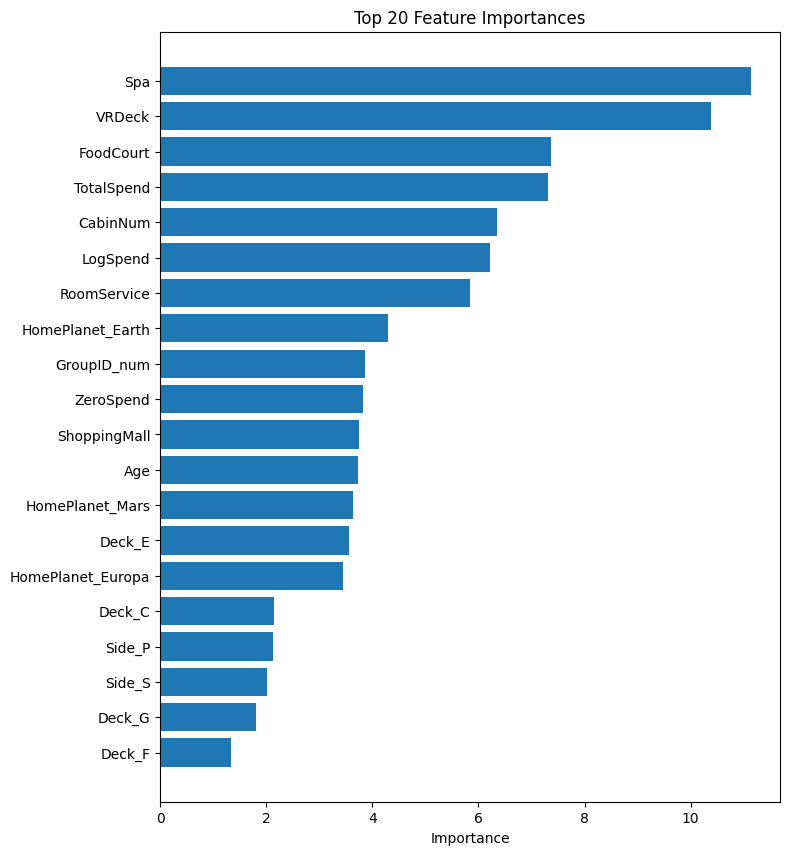

In [75]:
# ============================
# 1. Extract feature names
# ============================

from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

def get_ct_feature_names(ct):
    """
    Robustly extract feature names from a ColumnTransformer,
    even when transformers expand columns (e.g., OneHotEncoder).
    """
    output = []
    for name, transformer, cols in ct.transformers_:
        if name == "remainder":
            continue
        
        # If transformer has get_feature_names_out, use it
        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(cols)
        else:
            # Otherwise, just use the original column names
            names = cols
        
        output.extend(names)
    
    return output

# Get feature names from the preprocessing step
pre = final_model.named_steps["preprocess"]
feature_names = get_ct_feature_names(pre)

print("Number of feature names:", len(feature_names))


# ============================
# 2. Extract CatBoost importances
# ============================

clf = final_model.named_steps["clf"]
importances = clf.get_feature_importance()

print("Number of importances:", len(importances))


# ============================
# 3. Combine into a DataFrame
# ============================

# Safety check
if len(feature_names) != len(importances):
    print("WARNING: Length mismatch!")
else:
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    display(fi.head(20))


# ============================
# 4. Optional: Plot top features
# ============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.barh(fi.head(20)["Feature"], fi.head(20)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()



### Interpretation
- Spending behavior is a very important signal in the dataset.
- Cabin location is the next highest category as a signal.
- The GroupID was meaningful - People in the same group tended to have similar results
- Demographics like home planet and age also have predictive power, but not as much as spending and cabin location.

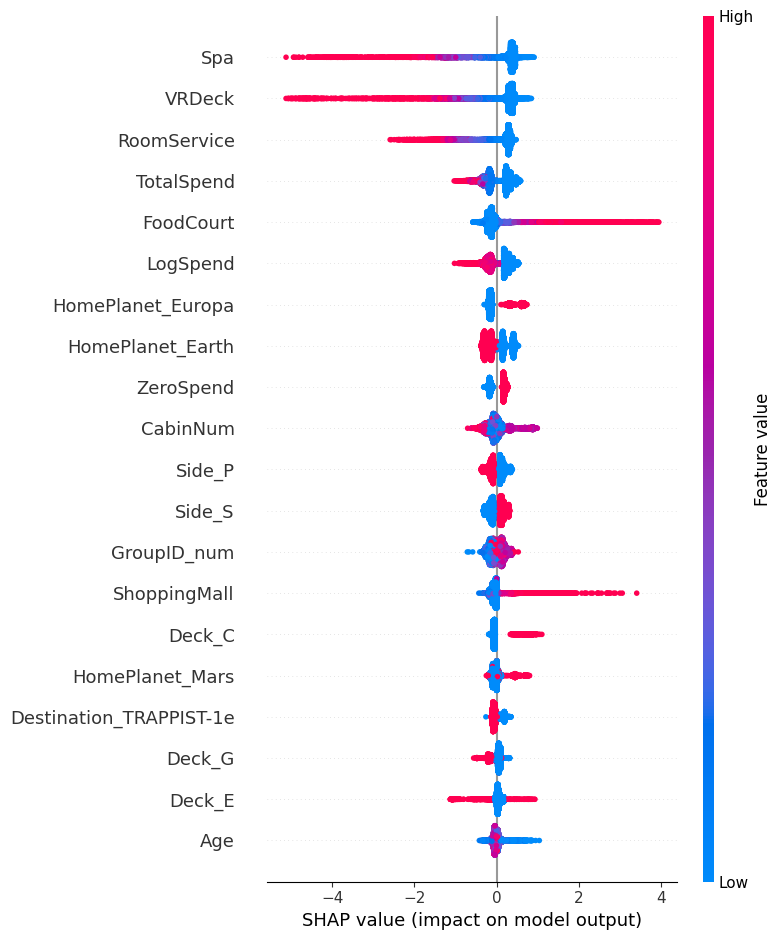

In [78]:
import shap
import numpy as np

# 1. Extract the trained CatBoost model
clf = final_model.named_steps["clf"]

# 2. Extract the preprocessor
pre = final_model.named_steps["preprocess"]

# 3. Transform the training data into model-ready form
X_train_transformed = pre.transform(X_train)

# 4. Initialize SHAP TreeExplainer for CatBoost
explainer = shap.TreeExplainer(clf)

# 5. Compute SHAP values
shap_values = explainer.shap_values(X_train_transformed)

# 6. Get feature names
feature_names = get_ct_feature_names(pre)

# 7. Summary plot (global importance + direction)
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


### Interpretation
 - Spending on things like Spa, VR Deck and Room Service made you less likely to be transported
 - Spending on Foodcourt and Shopping mall made you more likely to be transported.
 - Being from Europa made you more likely to be transported.  Being from Earth made you less likely.

## Conclusion

This project resulted in a tuned CatBoost model that achieved a cross-validated accuracy of 0.819 and a public leaderboard score of 0.80523 (rank 517 in the 2-month rolling leaderboard.)  There are opportunities for future refinements... maybe trying some categorical handling.  As a first Kaggle submission, though, I'm really pleased with how this ended up.